In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

In [2]:
# defining the imshow function
def imshow(title = 'Image',image = None,size = 10):
    w,h = image.shape[1],image.shape[0]
    aspect_ratio = w/h
    plt.figure(figsize=(size*aspect_ratio,size))
    plt.imshow(cv2.cvtColor(image,cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.show()


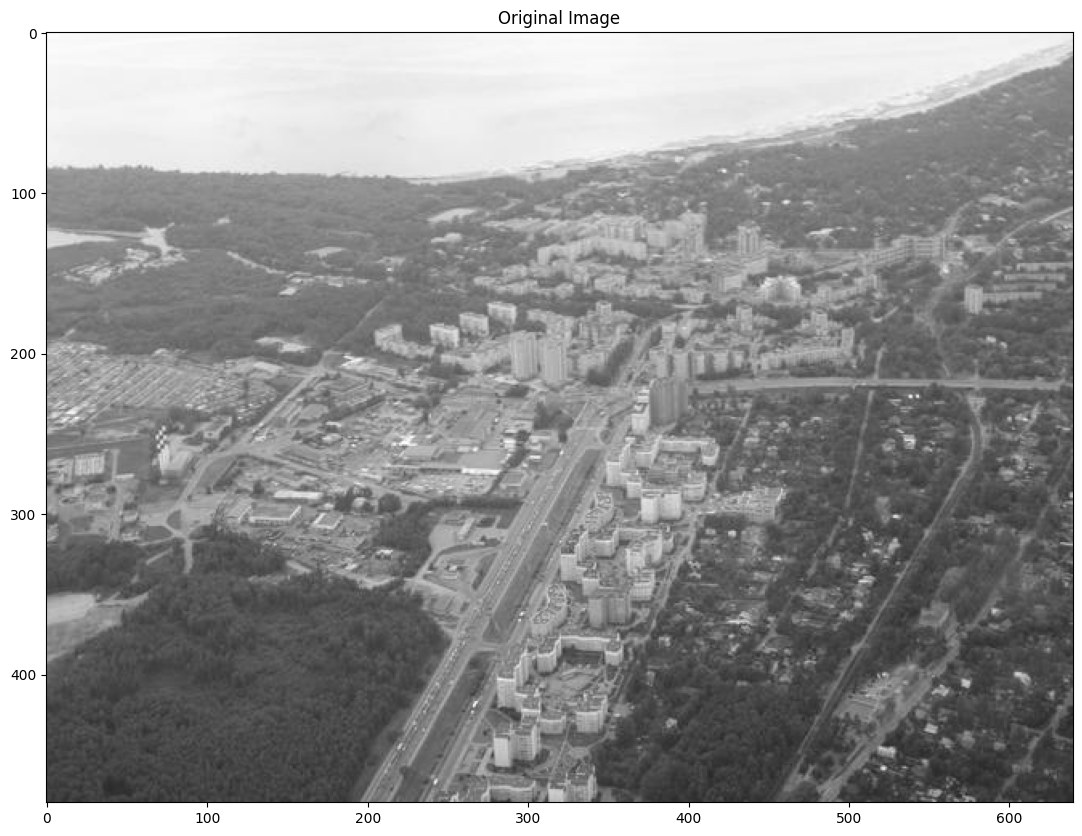

In [3]:
# Dilation - Adds pixel to the boundaries of objects in an image
# Erosion - Removes the pixel at the boundaries of objects in an image 
# opening - erosion followed by dilation 
# closing - dilation followed by erosion 

img = cv2.imread('C:\\Users\\abhin\\OneDrive\\Documents\\GitHub\\Computer-Vision\\data\\aero3.jpg',0)
imshow('Original Image',img)

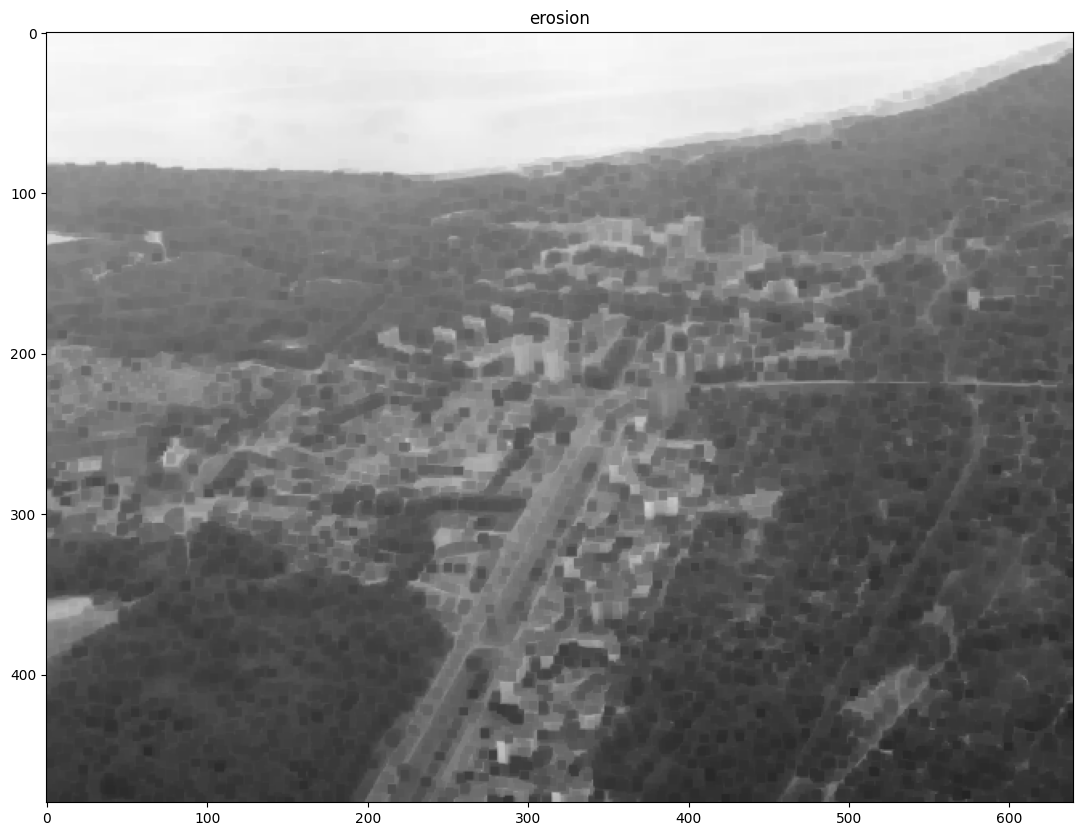

In [4]:
# lets define a kernel size

kernel = np.ones((5,5),np.uint8)


# now we erode 

erosion = cv2.erode(img,kernel,iterations = 1)
imshow('erosion',erosion)

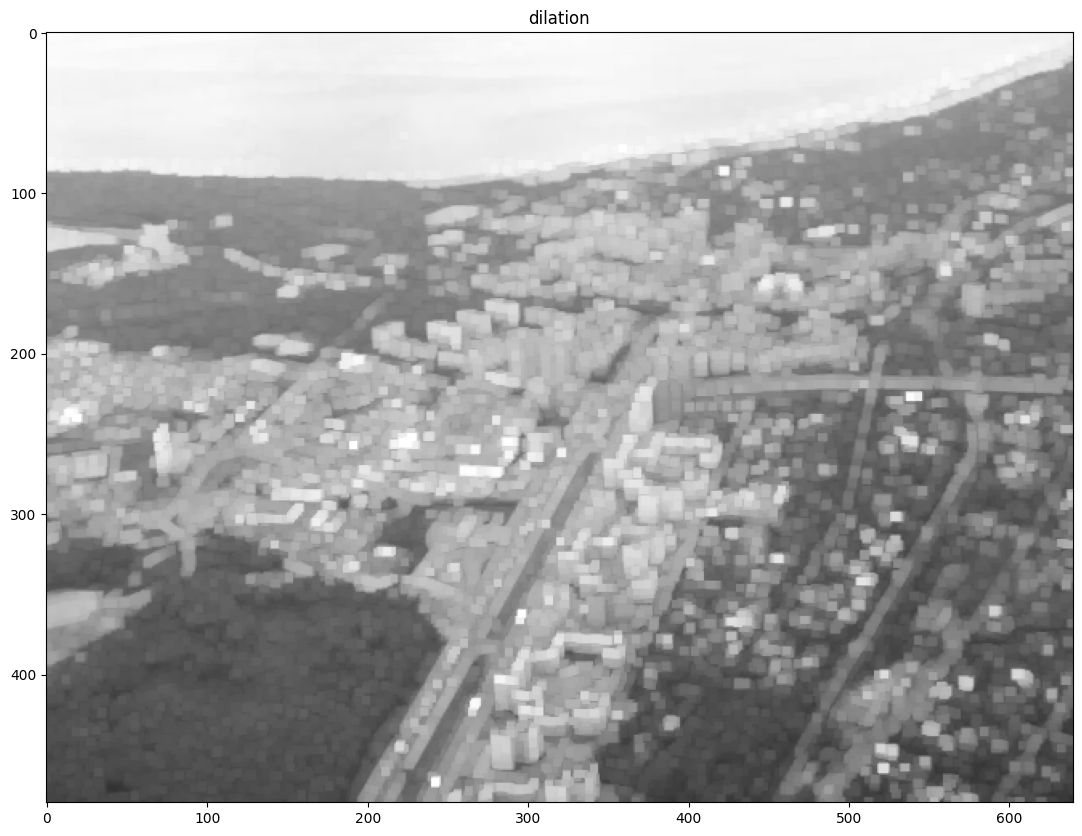

In [5]:
# now we dilate 

dilation = cv2.dilate(img,kernel,iterations = 1)
imshow('dilation',dilation)

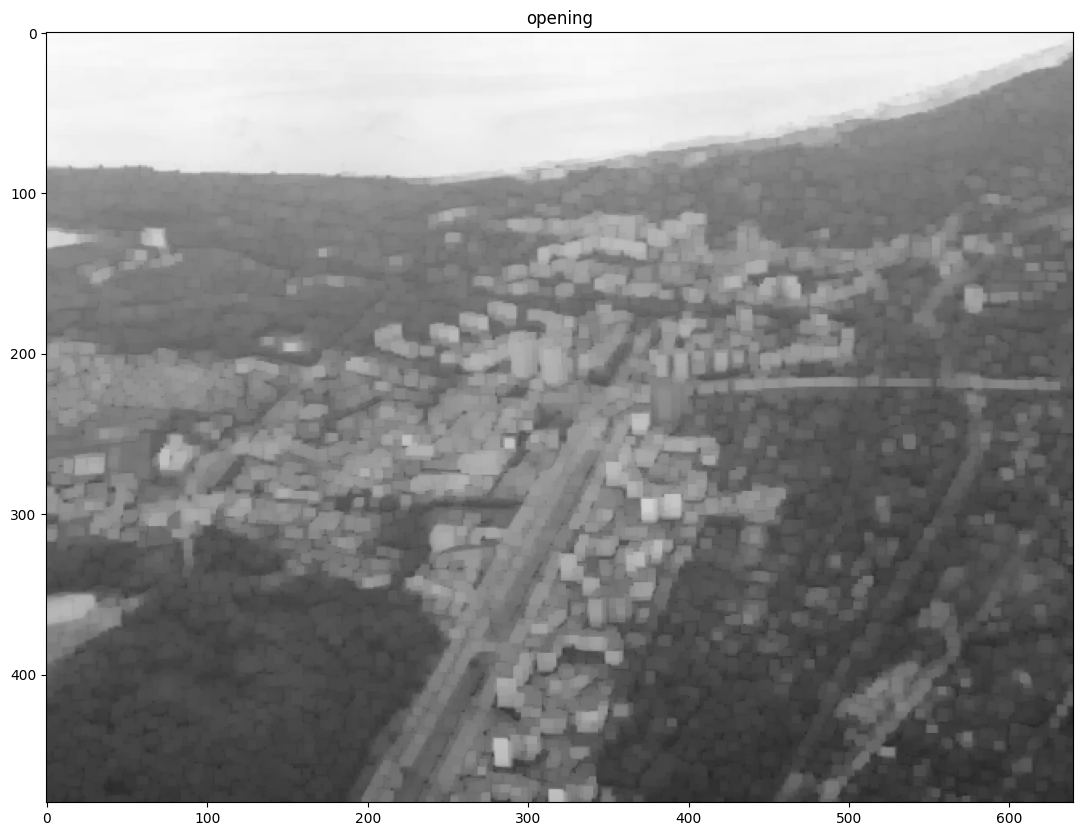

In [6]:
# Opening - Erosion followed by dilation

opening = cv2.morphologyEx(img,cv2.MORPH_OPEN,kernel)
imshow('opening',opening)

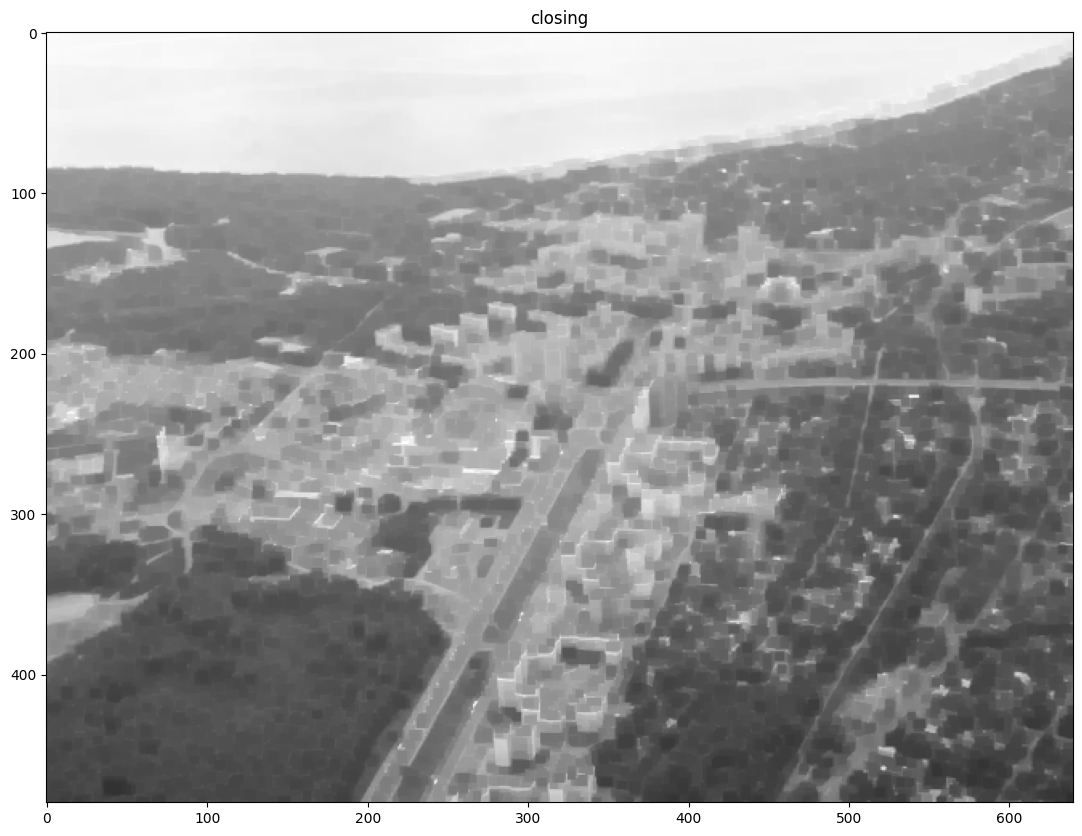

In [7]:
# Closing - Dilation followed by erosion

closing = cv2.morphologyEx(img,cv2.MORPH_CLOSE,kernel)
imshow('closing',closing)

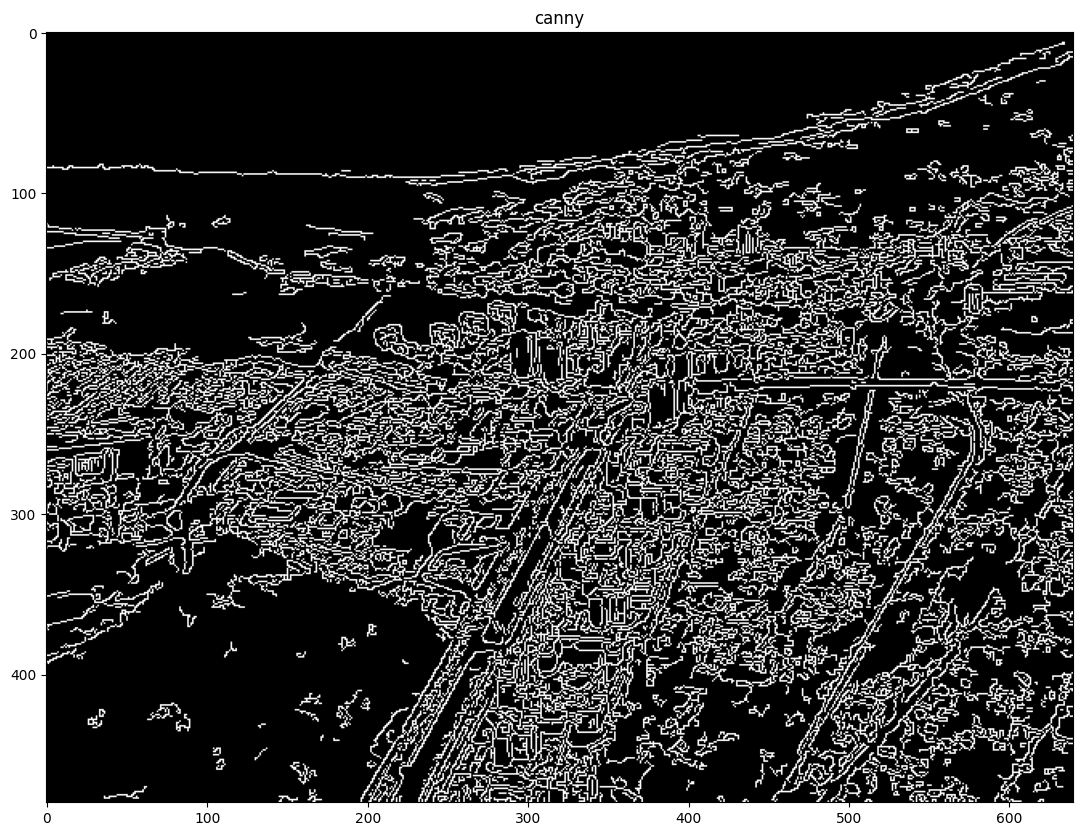

In [8]:
# Canny Edge Detection - uses gradient values as thresholds

canny = cv2.Canny(img,50,120) # expects lots of edges
imshow('canny',canny)

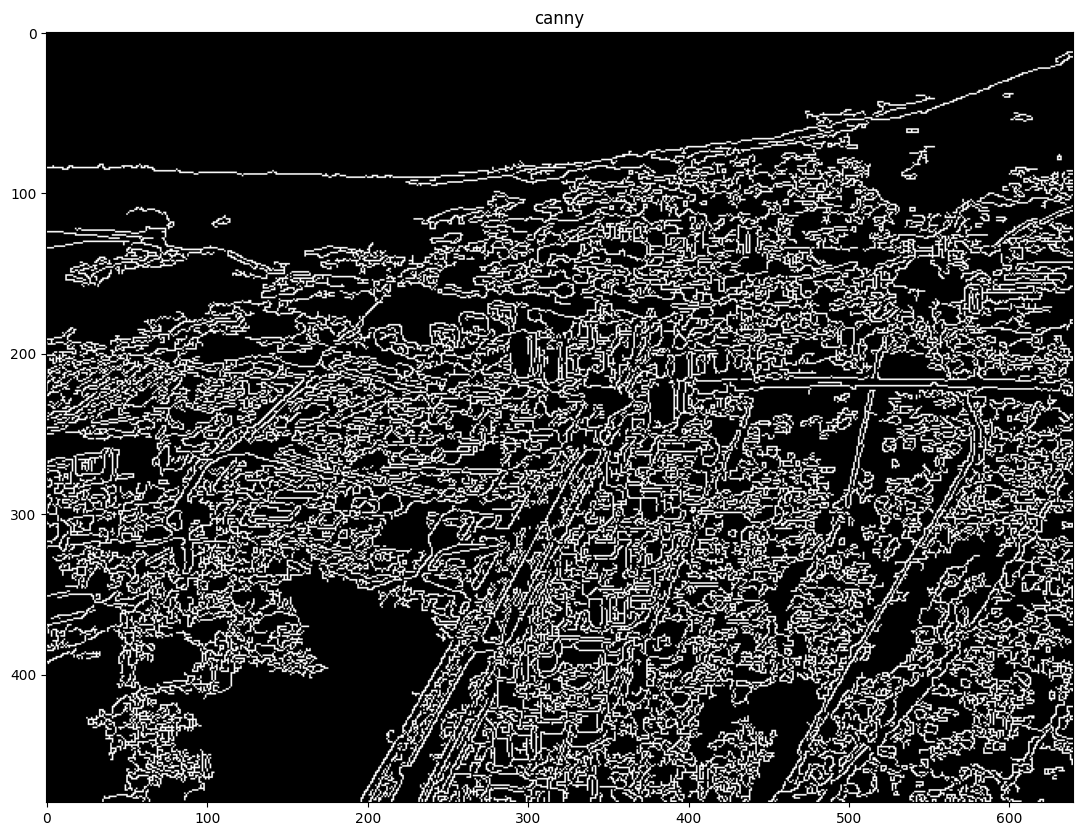

In [9]:
# wide edge threshold expects lots of edges 
canny = cv2.Canny(img,10,200) 
imshow('canny',canny)

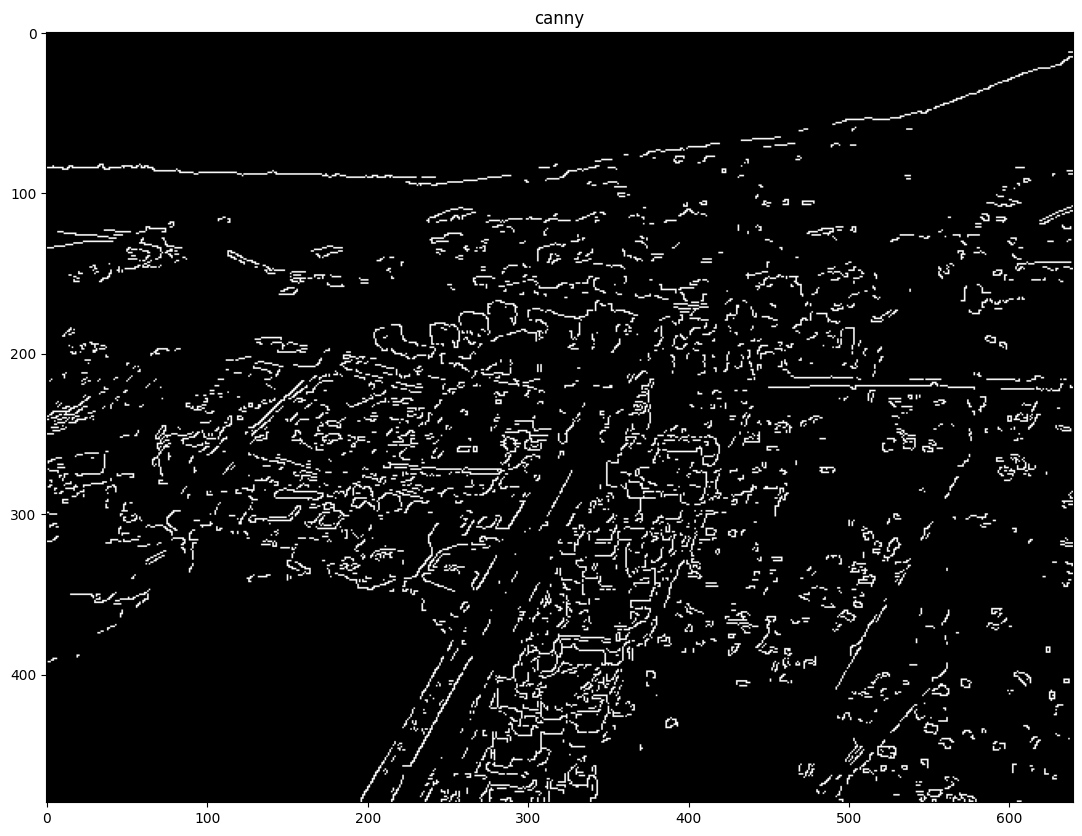

In [10]:
# narrow threshold expects only strong edges

canny = cv2.Canny(img,200,240)
imshow('canny',canny)

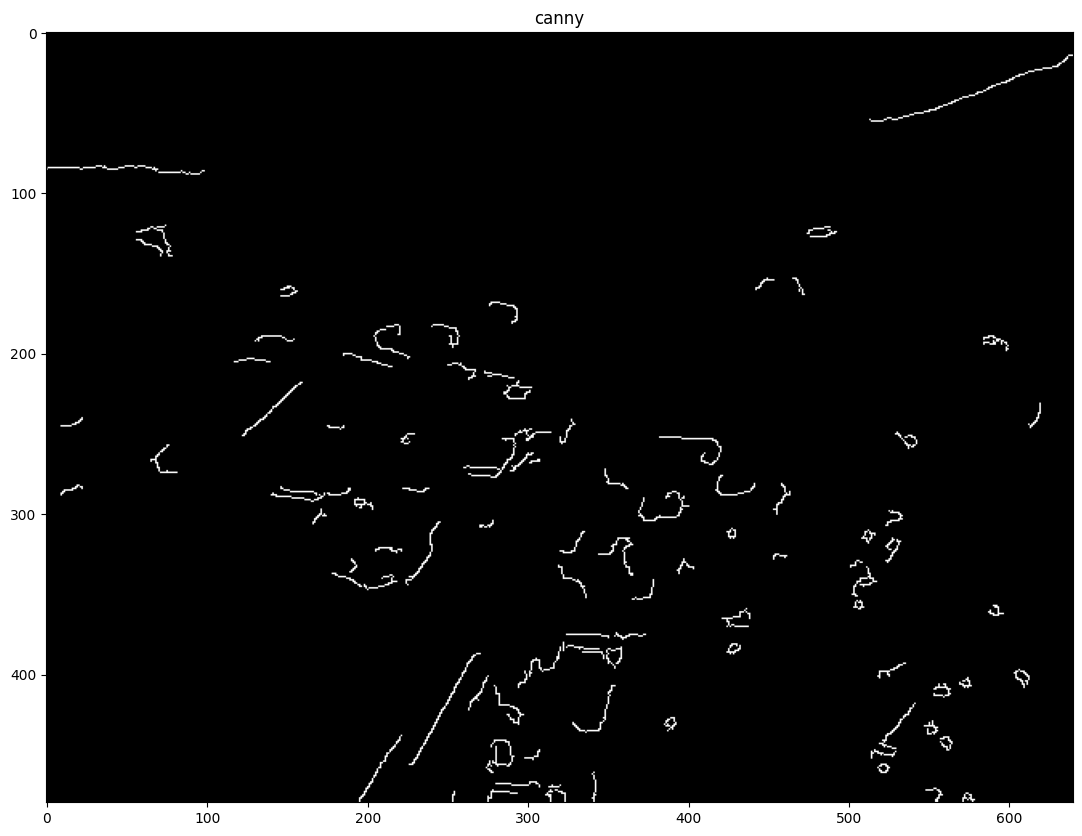

In [11]:
# Auto Canny Edge Detection

def auto_canny(image):
    # finds optimal threshold values using median of the image
    median = np.median(image)
    blurred_img = cv2.blur(image,ksize=(5,5))
    lower = int(max(0,(1.0-0.33)*median))
    upper = int(min(255,(1.0+0.33)*median))
    edges = cv2.Canny(blurred_img,lower,upper)
    return edges

canny = auto_canny(img)
imshow('canny',canny)